# EnSF Heat Equation: Visualizations

Loads HDF5 results from `01_run_experiment.ipynb` and reproduces the
figures used in the thesis (Chapter 3).

**Figures produced:**
- Field snapshots: true state, observations, EnSF estimate at selected times
- RMSE over time for 100%, 25%, and 5% observation densities

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from pathlib import Path

DATA_DIR    = Path("../data")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FILE_FORMAT = "pdf"  # or 'png'

## Helper functions

In [2]:
def load_h5(tag: str) -> dict:
    """Load all datasets and attributes from an HDF5 results file."""
    h5_path = DATA_DIR / f"{tag}.h5"
    data = {}
    with h5py.File(h5_path, "r") as f:
        for key in f.attrs:
            data[key] = f.attrs[key]
        for key in f.keys():
            data[key] = f[key][:]
    return data


def plot_field(triangulation, values, title="", vmin=None, vmax=None,
               save_path=None, file_format=FILE_FORMAT):
    """Plot a scalar field on the triangulated mesh."""
    fig, ax = plt.subplots(figsize=(4, 4))
    tc = ax.tripcolor(triangulation, values, shading="gouraud",
                      cmap="viridis", vmin=vmin, vmax=vmax)
    fig.colorbar(tc, ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=11)
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", format=file_format)
        print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)

## Load results

In [3]:
res100 = load_h5("heat_obs100")
res25  = load_h5("heat_obs25")
res5   = load_h5("heat_obs5")

# Build triangulation from mesh (same for all experiments)
coords = res100["mesh_coords"]
tri = Triangulation(coords[:, 0], coords[:, 1])

print(f"State dim: {coords.shape[0]}, N steps: {res100['N']}")

State dim: 1681, N steps: 100


## Figure 1: Field snapshots at selected times

Shows true state, (sparse) observations, and EnSF estimate side by side.

Saved: ../figures/heat_obs25_true_t25.pdf


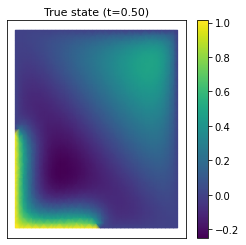

Saved: ../figures/heat_obs25_obs_t25.pdf


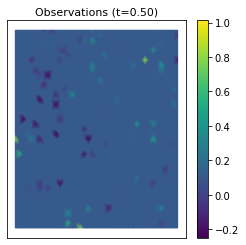

Saved: ../figures/heat_obs25_est_t25.pdf


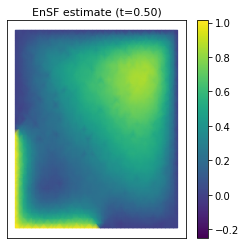

Saved: ../figures/heat_obs25_true_t50.pdf


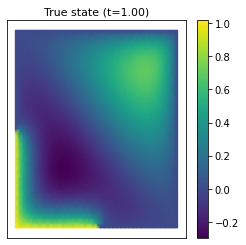

Saved: ../figures/heat_obs25_obs_t50.pdf


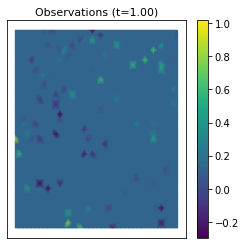

Saved: ../figures/heat_obs25_est_t50.pdf


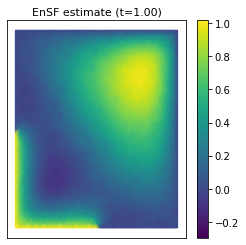

Saved: ../figures/heat_obs25_true_t100.pdf


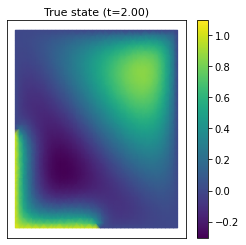

Saved: ../figures/heat_obs25_obs_t100.pdf


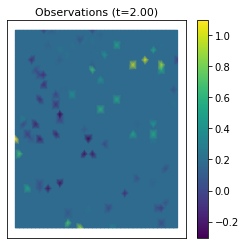

Saved: ../figures/heat_obs25_est_t100.pdf


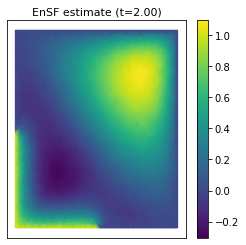

In [6]:
def plot_snapshot_row(res, step_idx: int, tag: str):
    """
    Plot true state, observations, and EnSF estimate at a given time step.
    step_idx is 1-indexed (first assimilation step = 1).
    """
    true_field = res["XTrue"][step_idx]
    obs_field  = res["obs_save"][step_idx - 1]  # obs_save is 0-indexed
    est_field  = res["EnSF_est"][step_idx]

    all_vals = np.concatenate([true_field, est_field])
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

    t_val = res["time"][step_idx - 1]

    plot_field(tri, true_field, title=f"True state (t={t_val:.2f})",
               vmin=vmin, vmax=vmax,
               save_path=FIGURES_DIR / f"{tag}_true_t{step_idx}.{FILE_FORMAT}")

    # Observations: replace NaN with mean for visualization
    obs_vis = np.where(np.isnan(obs_field), np.nanmean(obs_field), obs_field)
    plot_field(tri, obs_vis, title=f"Observations (t={t_val:.2f})",
               vmin=vmin, vmax=vmax,
               save_path=FIGURES_DIR / f"{tag}_obs_t{step_idx}.{FILE_FORMAT}")

    plot_field(tri, est_field, title=f"EnSF estimate (t={t_val:.2f})",
               vmin=vmin, vmax=vmax,
               save_path=FIGURES_DIR / f"{tag}_est_t{step_idx}.{FILE_FORMAT}")


# Example: snapshot at t=1 (step 50) and final time (step 100)
for step in [25, 50, 100]:
    #plot_snapshot_row(res100, step, tag="heat_obs100")
    plot_snapshot_row(res5,  step, tag="heat_obs25")

## Figure 2: RMSE over time — all observation densities

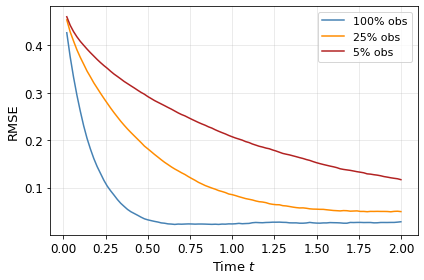

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

for res, label, color in [
    (res100, "100% obs", "steelblue"),
    (res25,  "25% obs",  "darkorange"),
    (res5,   "5% obs",   "firebrick"),
]:
    ax.plot(res["time"], res["step_rmse"],
            label=label, color=color, linewidth=1.5)

ax.set_xlabel("Time $t$", fontsize=13)
ax.set_ylabel("RMSE", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.tick_params(labelsize=12)

fig.tight_layout()
fig.savefig(FIGURES_DIR / f"heat_rmse_comparison.{FILE_FORMAT}",
            bbox_inches="tight", format=FILE_FORMAT)
plt.show()